In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import pyrex
#import pyrex.custom.ara as ara
from pyrex.internal_functions import normalize
import os
import sys
import seaborn as sns
import polReco_util as util
import scipy

import ROOT
from ROOT import TCanvas, TGraph
from ROOT import gROOT
from ROOT import gInterpreter, gSystem
from ROOT import TChain, TSelector, TTree
from scipy.stats import norm
from scipy.stats import rayleigh


gInterpreter.ProcessLine('#include "/cvmfs/ara.opensciencegrid.org/trunk/centos7/source/libRootFftwWrapper/include/FFTtools.h"')

gSystem.Load('/users/PAS0654/jflaherty13/source/AraRoot/AraRoot_build/lib/libAraEvent.so')
gSystem.Load("/cvmfs/ara.opensciencegrid.org/trunk/centos7/source/libRootFftwWrapper/build/libRootFftwWrapper.so")

gInterpreter.ProcessLine('#include "/users/PAS0654/jflaherty13/source/AraSim/Position.h"')
gInterpreter.ProcessLine('#include "/users/PAS0654/jflaherty13/source/AraSim/Report.h"')
gInterpreter.ProcessLine('#include "/users/PAS0654/jflaherty13/source/AraSim/Detector.h"')
gInterpreter.ProcessLine('#include "/users/PAS0654/jflaherty13/source/AraSim/Settings.h"')
gInterpreter.ProcessLine('#include "/users/PAS0654/jflaherty13/source/AraSim/IceModel.h"')
gInterpreter.ProcessLine('#include "/users/PAS0654/jflaherty13/source/AraSim/EarthModel.h"')
gInterpreter.ProcessLine('#include "/users/PAS0654/jflaherty13/source/AraSim/Event.h"')
gInterpreter.ProcessLine('#include "/users/PAS0654/jflaherty13/source/AraSim/Spectra.h"')

# mpl.use('agg') 
mpl.rcParams['text.usetex'] = True
#mpl.rcParams['text.latex.preamble'] = [r'\usepackage{amsmath}'] #for \text command
#mpl.rcParams['text.latex.unicode'] = True
mpl.rcParams['mathtext.rm'] = 'Times New Roman'
mpl.rcParams['mathtext.it'] = 'Times New Roman:italic'
mpl.rcParams['mathtext.bf'] = 'Times New Roman:bold'

mpl.rc('font', family='serif', size=12)
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['ytick.major.size'] = 5

mpl.rcParams['axes.titlesize'] = 18
mpl.rcParams['axes.labelsize'] = 18
mpl.rc('font', size=16)
mpl.rc('axes', titlesize=20)

#current_palette = sns.color_palette('colorblind', 10)
current_palette = sns.color_palette('bright', 10)

/cvmfs/ara.opensciencegrid.org/trunk/RHEL_7_x86_64/root_build/lib/cppyy/__init__.py:72: DeprecationWarning: invalid escape sequence \d
  if re.match('^libcppyy_backend\d_\d$', lib_name):


Welcome to JupyROOT 6.22/06


Warning in <TClassTable::Add>: class FFTtools::AnalyticSignal already in TClassTable
Warning in <TClassTable::Add>: class FFTtools::CompositeSignal already in TClassTable
Warning in <TClassTable::Add>: class FFTtools::BandlimitedSampledSignal already in TClassTable
Warning in <TClassTable::Add>: class FFTtools::ThermalNoise already in TClassTable
Warning in <TClassTable::Add>: class FFTtools::Averager already in TClassTable
Warning in <TClassTable::Add>: class FFTtools::CWT already in TClassTable
Warning in <TClassTable::Add>: class FFTtools::CWT::MotherWavelet already in TClassTable
Warning in <TClassTable::Add>: class FFTtools::CWT::Ricker already in TClassTable
Warning in <TClassTable::Add>: class FFTtools::CWT::Ridger already in TClassTable
Warning in <TClassTable::Add>: class FFTtools::CWT::Morlet already in TClassTable
Warning in <TClassTable::Add>: class FFTtools::DigitalFilter already in TClassTable
Warning in <TClassTable::Add>: class FFTtools::DigitalFilterSeries already in T

In [2]:
#no birefringence
station=2
run="45"
rawSrcFolder = "deconvolvedWaveforms_run_"+str(run)+".root"

# rawSrcFolder = "/users/PAS0654/jflaherty13/source/AraSim/outputs/20240404_TxTroubleshooting/A"+str(station)+"/birefringence/AraOut.setup_TxSimulation_A"+str(station)+".txt.run1000.root"
# rawSrcFolder = "/users/PAS0654/jflaherty13/source/AraSim/outputs/20240404_TxTroubleshooting/A"+str(station)+"/birefringence/deconvolvedWaveforms_run_1000.root"

rawFilename = rawSrcFolder

In [3]:
# print("runNumber = " + str(runNumber))
print("Sourcing raw data from " + str(rawSrcFolder))

Sourcing raw data from deconvolvedWaveforms_run_45.root


In [4]:
rawInputFile = ROOT.TFile.Open(rawFilename)

file_list = []
file_list.append(rawFilename)

eventTree = TChain("eventTree") #Define chain and tree that needs to be read. "VTree" in this case.
simSettingsTree = TChain("AraTree")
simTree = TChain("AraTree2")
cswTree = TChain("coherentSum")

for line in file_list:
    eventTree.AddFile(line)
    simTree.AddFile(line)
    simSettingsTree.AddFile(line)
    cswTree.AddFile(line)

reportPtr = ROOT.Report()#report pointer
eventPtr = ROOT.Event()
detectorPtr = ROOT.Detector()
interactionPtr = ROOT.Interaction()
stationPtr = ROOT.ARA_station()

usefulEvent = ROOT.UsefulAtriStationEvent()
rawEvent = ROOT.RawAtriStationEvent()

dataLike = False
try:
    eventTree.SetBranchAddress("UsefulAtriStationEvent",ROOT.AddressOf(usefulEvent))
    eventTree.SetBranchAddress("RawAtriStationEvent",ROOT.AddressOf(rawEvent))

    totalRawEvents = eventTree.GetEntries()
    print('total raw events:', totalRawEvents) 
    
except TypeError:
    print("Open as Simulated Data Failed.  Attempting Open as Real Data")
    dataLike = True
    rawInputFile = ROOT.TFile.Open(rawFilename)

    eventTree = rawInputFile.Get("eventTree")

    rawEvent = ROOT.RawAtriStationEvent()
    eventTree.SetBranchAddress("event",ROOT.AddressOf(rawEvent))

    totalRawEvents = eventTree.GetEntries()
    print('total raw events:', totalRawEvents)

usefulEventCsw = ROOT.UsefulAtriStationEvent()
# try:
cswTree.SetBranchAddress("UsefulAtriStationEvent",ROOT.AddressOf(usefulEventCsw))
    
# except TypeError:
#     print("CSW Tree not found!")
    

total raw events: 1


0

In [5]:
# usefulEventCsw.getGraphFromRFChan(0)

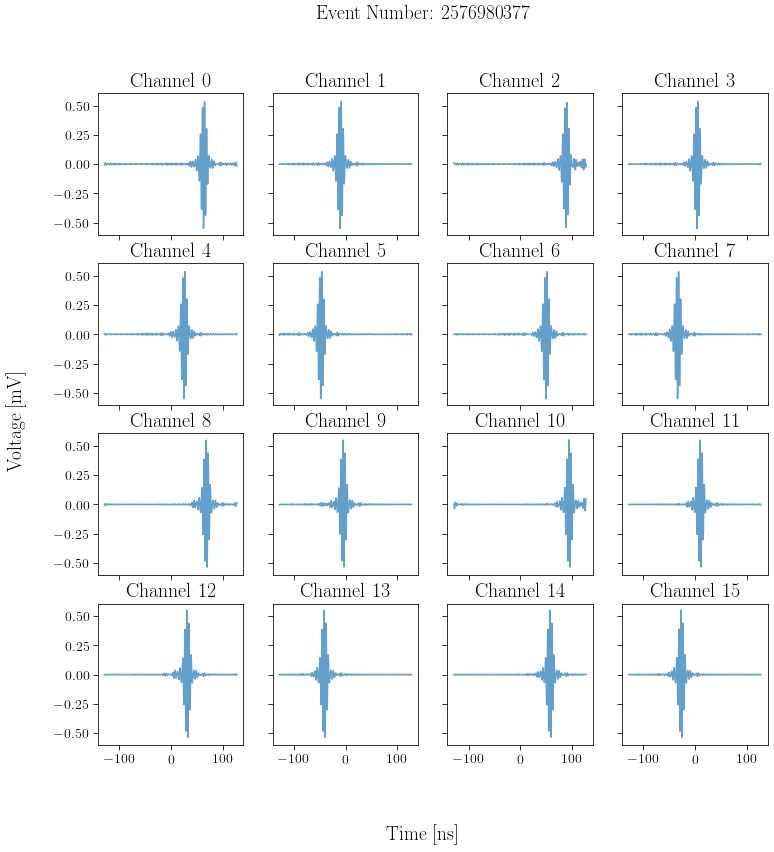

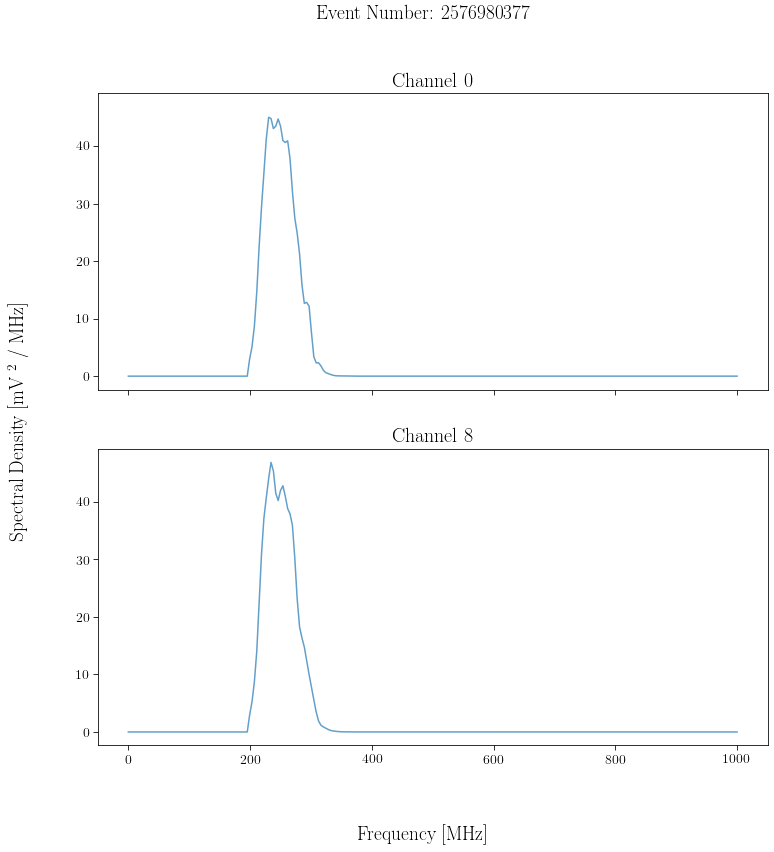

***NOTE***: Year/Unixtime argument is 0. If you want the correct channel mappings for ARA03 & ARA01 for 2018 & after please specify either: 
a) The right year when you call AraGeomTool::getStationInfo(3,2017) where 3 is stationID and 2017 is DB year
b) The Unixtime of any event at the chosen run when you call AraGeomTool::getStationInfo(3,1000000000) where 3 is stationID and 1000000000 is unixtime
OR
c) Call UsefulAtriStationEvent *realAtriEvPtr = new UsefulAtriStationEvent(rawAtriEvPtr, AraCalType::kLatestCalib); ***BEFORE*** 
AraGeomTool::getStationInfo(3,2017)
Opening 2013-2017 SQliteDB using AraGeomTool::getStationInfo()
Opening default 2013-2017 SQLite tables for all stations 


In [6]:
evt = 0
eventTree.GetEntry(evt)
fig, axes = util.plotWaveform(usefulEvent)
fig, axes = util.plotWaveform(usefulEvent, FFT=True, channelPair=0)


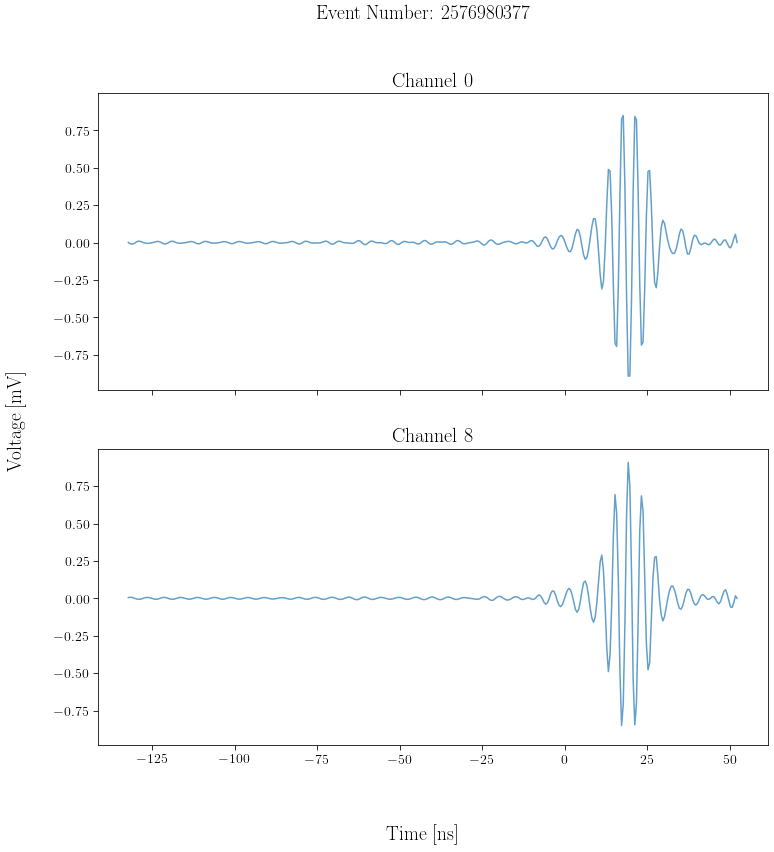

In [7]:
evt = 0
cswTree.GetEntry(evt)
fig, axes = util.plotWaveform(usefulEventCsw, csw=True)


envelopePeakPrimary = 0.9712817540375343
envelopePeakPrimary = 0.9712817540375343
envelopePeakPrimary = 0.9712817540375343
envelopePeakPrimary = 0.9712817540375343
envelopePeakPrimary = 0.9712817540375343
envelopePeakPrimary = 0.9712817540375343
envelopePeakPrimary = 0.9712817540375343
envelopePeakPrimary = 0.9712817540375343


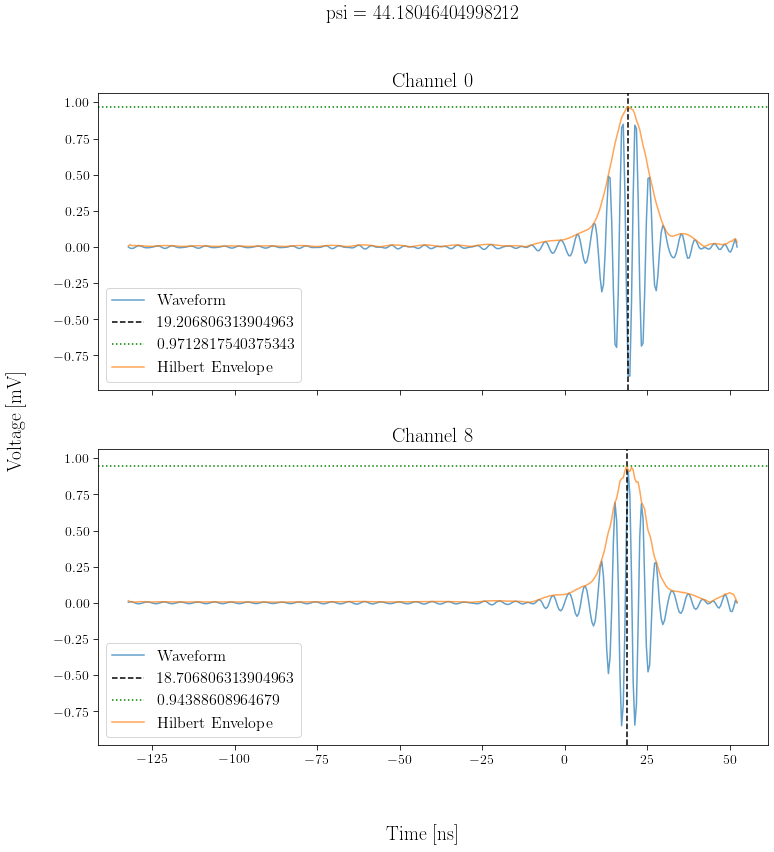

In [8]:
evt = 0
cswTree.GetEntry(evt)
fig, axes = util.plotWaveformMarkPeaks(usefulEventCsw, showPeaks=True, Hilbert=True, channelPair=0)
for ax in axes.flatten():
    ax.legend()

In [9]:
cswTree.Show()

======> EVENT:0
 UsefulAtriStationEvent = (UsefulAtriStationEvent*)0xaa5fab0
 fUniqueID       = 0
 fBits           = 50331648
 softVerMajor    = 3
 softVerMinor    = 14
 typeId          = 153
 verId           = 153
 subVerId        = 153
 stationId       = 2
 reserved        = 39321
 numBytes        = 2576980377
 checksum        = 39321
 unixTime        = 11068046444225730969
 unixTimeUs      = 2576980377
 eventNumber     = 2576980377
 ppsNumber       = 2576980377
 numStationBytes = 2576980377
 timeStamp       = 2576980377
 eventId         = 2576980377
 versionId       = 39321
 numReadoutBlocks = 39321
 triggerInfo[4]  = 2576980377 , 2576980377 , 2576980377 , 2576980377 

 triggerBlock[4] = 153 , 153 , 153 , 153 

 filterInfo      = 153
 fNumChannels    = 0
 fTimes          = (map<int,vector<double> >*)0xaa5fbd0
 fTimes.first    = 0, 1, 2, 3, 8, 9, 10, 11, 16, 17, 18, 19, 24, 25, 26, 27
 fTimes.second   = (vector<double>*)0xb5c48c8, (vector<double>*)0xb595548, (vector<double>*)0xb5b8bb

In [10]:
usefulEventCsw

In [11]:
usefulEvent

In [12]:
eventTree.Show()

======> EVENT:0
 UsefulAtriStationEvent = (UsefulAtriStationEvent*)0xa6ce910
 fUniqueID       = 0
 fBits           = 50331648
 softVerMajor    = 3
 softVerMinor    = 14
 typeId          = 153
 verId           = 153
 subVerId        = 153
 stationId       = 2
 reserved        = 39321
 numBytes        = 2576980377
 checksum        = 39321
 unixTime        = 11068046444225730969
 unixTimeUs      = 2576980377
 eventNumber     = 2576980377
 ppsNumber       = 2576980377
 numStationBytes = 2576980377
 timeStamp       = 2576980377
 eventId         = 2576980377
 versionId       = 39321
 numReadoutBlocks = 39321
 triggerInfo[4]  = 2576980377 , 2576980377 , 2576980377 , 2576980377 

 triggerBlock[4] = 153 , 153 , 153 , 153 

 filterInfo      = 153
 fNumChannels    = 0
 fTimes          = (map<int,vector<double> >*)0xa6cea30
 fTimes.first    = 0, 1, 2, 3, 8, 9, 10, 11, 16, 17, 18, 19, 24, 25, 26, 27
 fTimes.second   = (vector<double>*)0xaa49198, (vector<double>*)0xaa6d688, (vector<double>*)0xaa6d73

In [13]:
eventTree.fVolts

<cppyy.gbl.std.map<int,vector<double> > object at 0xa6cea90>

In [14]:
cswTree.fVolts

<cppyy.gbl.std.map<int,vector<double> > object at 0xaa5fc30>

In [15]:
np.array(usefulEvent.fVolts[0]).max()

0.5338938504287982

(-11.0, 11.0)

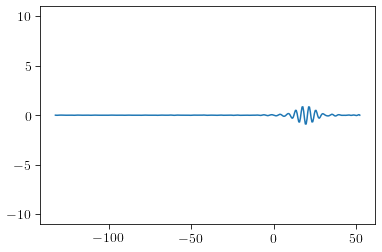

In [16]:
voltageVpolCsw = np.array(usefulEventCsw.fVolts[0])
timeCsw = np.array(usefulEventCsw.fTimes[0])
plt.plot(timeCsw,voltageVpolCsw)
plt.ylim([-11,11])

(-11.0, 11.0)

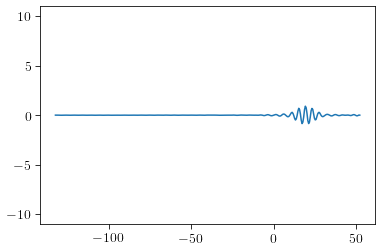

In [17]:
voltageHpolCsw = np.array(usefulEventCsw.fVolts[2])
timeCsw = np.array(usefulEventCsw.fTimes[0])
plt.plot(timeCsw,voltageHpolCsw)
plt.ylim([-11,11])